Feynman diagrams integration

Let's calculate density of states:

$$\rho_{\eta}(\omega) =   \int_{BZ}  \frac{d^{3}k}{(2 \pi)^{3}} \frac{1}{\pi} \frac{\eta}{(\omega - \epsilon(\mathbf{k}))^{2} + \eta^{2}}$$

nearest-neighbour 3D cubic tight binding band $\epsilon (\mathbf{k}) = -2 b (\cos(k_{x}) + \cos(k_{y}) + \cos(k_{z}))$

Brillouin zone $k_{x}, k_{y}, k_{z} \in [- \pi, \pi]$

band range $\epsilon \in [-6b, 6b]$

Scalar DOS: $f_{\eta}(\omega, k_{x}, k_{y}, k_{z}) = \frac{1}{\pi} \frac{\eta}{(\omega - \epsilon(k_{x},k_{y}, k_{z}))^{2} + \eta^{2}}$

For a fixed $\omega$ calculate $\rho_{\eta}(\omega)=\int_{-\pi}^{\pi} \int_{-\pi}^{\pi} \int_{-\pi}^{\pi} \frac{dk_{x} dk_{y} dk_{z}}{(2\pi)^{3}} f_{\eta}(\omega, k_{x}, k_{y}, k_{z})$

First quadraure approximation: 

We select a uniform grid $k_{j} = - \pi + \frac{2\pi j}{N}, \quad j= 0, \dots, N-1$ and approximate:

$$\rho_{\eta} (\omega) \approx \frac{1}{N^{3}} \sum_{j_{x}, j_{y}, j_{z}} \frac{1}{\pi} \frac{\eta}{(\omega - \epsilon_{j_{x}, j_{y}, j_{z}})^{2} + \eta^{2}}.$$

In [8]:
import numpy as np
import numba

@numba.njit
def epsilon_from_cos(b, cx, cy, cz):
    return -2.0 * b * (cx + cy + cz)

@numba.njit
def quadrature(N, b, eta, omega):
    # Numba-friendly replacement for:
    # kj = np.linspace(-np.pi, np.pi, N, endpoint=False)
    kj = np.arange(N) * (2.0 * np.pi / N) - np.pi
    cos_k = np.cos(kj)
    sum_of_parts, compensation = 0.0, 0.0
    for i in range(N):
        cx = cos_k[i]
        for j in range(N):
            cy = cos_k[j]
            for l in range(N):
                cz = cos_k[l]
                eps = epsilon_from_cos(b, cx, cy, cz)
                denominator = (omega - eps)**2 + eta**2
            
                # Kahan summation (for accumulation accuracy, floating point error) 
                term = 1.0 / denominator
                y = term - compensation
                t = sum_of_parts + y
                compensation = (t - sum_of_parts) - y
                sum_of_parts = t
    factor = eta / (np.pi * N**3)
    return factor * sum_of_parts


N = 256 * 2
b = 1.0
eta = 0.1
omega = 0.5

r = quadrature(N, b, eta, omega)
print(r)


0.13973848060444236


In [4]:
#NOT CONNECTED TO HOMEWORK, JUST TO TEST QTT 
import xfacpy # tensor cross interpolation and QTT construction 
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, exp, pi

def f1d(x):
    return np.exp(-x**2) * np.cos(20*x) #1d test function

R = 16  # grid has 2^R points, we will try to create R dim binary tensor.
qgrid = xfacpy.QuanticsGrid(a=-np.pi, b=np.pi, nBit=R) # definition of quantics grid.
args = xfacpy.TensorCI2Param() # parameter object for tensor cross interpolation
args.bondDim = 20 # max bond dimension 
ci = xfacpy.QTensorCI(f1d=f1d, qgrid=qgrid, args=args) # QTCI 
for sweep in range(30): # for 30 iterations, improve interpolation pivots.
    ci.iterate()
    print(sweep, ci.pivotError[-1]) # list of error indicators generated during the algorithm 
    if ci.isDone():
        break

qtt = ci.get_qtt() # extract QTT

0 0.7496833721256164
1 3.744049937882341e-06
2 5.566946203039041e-10
3 1.6258606831053038e-13
4 4.99047489221857e-13


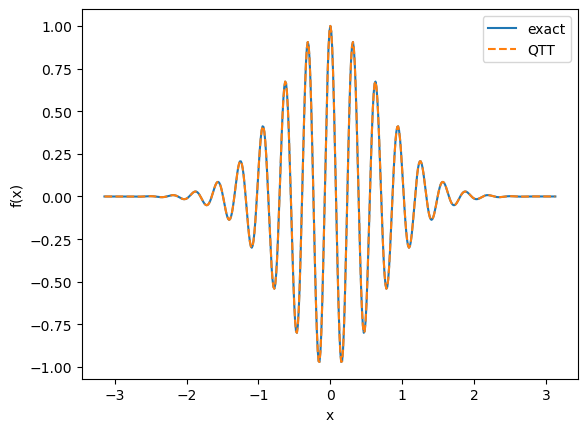

max abs error = 0.001345446589702426


In [6]:
xs = np.linspace(-np.pi, np.pi, 500, endpoint=False) # creating testing points.
f_exact = np.array([f1d(x) for x in xs])# forming exact values
f_qtt = np.array([qtt.eval([x]) for x in xs]) # evaluating QTT appoximations at each point. 
plt.plot(xs, f_exact, label="exact")
plt.plot(xs, f_qtt, "--", label="QTT")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()
print("max abs error = ", np.max(np.abs(f_exact - f_qtt)))

In [16]:
b = 1.0
eta = 0.1
omega = 0.5

# DOS integrand 
def epsilon(kx, ky, kz, b=1.0):
    return -2.0 * b * (np.cos(kx) + np.cos(ky) + np.cos(kz))

# Lorentzian spectral function
def spectral_function(arg): # multidimensional QTensorCI function takes onyl one argument 
    kx, ky, kz = arg
    eps = epsilon(kx, ky, kz, b=b)
    return (1.0 / np.pi) * eta / ((omega - eps)**2 + eta**2)

R = 12  # each k dimension has 2^R points
qgrid = xfacpy.QuanticsGrid(a=-np.pi, b=np.pi, dim=3, nBit=R) # def. the grid 
args = xfacpy.TensorCI2Param() # parameter object for tensor cross interpolation
args.bondDim = 120  # max bond dimension 
ci = xfacpy.QTensorCI(f=spectral_function, qgrid=qgrid, args=args) # QTCI
max_sweeps = 100
for sweep in range(max_sweeps): # for 40 iterations, improve interpolation pivots.
    ci.iterate()
    print(f"sweep {sweep+1:2d}, pivot error = {ci.pivotError[-1]:.3e}")
    if ci.isDone():
        break

qtt = ci.get_qtt()
I_qtt = qtt.integral()
rho_qtt = I_qtt / (2.0 * np.pi)**3 #normalise
print("QTT integral =", I_qtt)
print("rho qtt =", rho_qtt)

# for more accuracy: 
# first set higher bond dimension, just after that set a higher partition R.

sweep  1, pivot error = 2.235e+00
sweep  2, pivot error = 1.951e-01
sweep  3, pivot error = 1.171e+00
sweep  4, pivot error = 7.748e-07
sweep  5, pivot error = 9.159e-02
sweep  6, pivot error = 8.716e-01
sweep  7, pivot error = 4.533e+00
QTT integral = 34.877130566237355
rho qtt = 0.14060512217352483


$G_{0}(\mathbf{k}, i\omega_{n}) = \frac{1}{i \omega_{n} - \xi_{n}} = \frac{1}{i(2n +1)\pi T + 2t(\cos k_{x} + \cos k_{y} + \cos k_{z}) + \mu_{0}}$

In [ ]:
import numpy as np
import xfacpy

t = 1.0
mu0 = 0.0
T = 0.25
n = 0

omega_n = (2 * n + 1) * np.pi * T


def green0(arg):
    kx, ky, kz = arg
    epsilon_k = -2.0 * t * (np.cos(kx) + np.cos(ky) + np.cos(kz))
    xi_k = epsilon_k - mu0
    return complex(1.0 / (1j * omega_n - xi_k))

R = 20 # number of grid points 2^{R}
qgrid = xfacpy.QuanticsGrid(a=-np.pi, b=np.pi, dim=3, nBit=R, fused=False,)
params = xfacpy.TensorCI2Param()
params.bondDim = 60 # \chi_{max} maximum bond dimension  
params.reltol = 1.0e-10 # the scale to which current pivot error shuld be reduced based on the largest recorded sclale.

ci_g0 = xfacpy.QTensorCI_complex(f=green0, qgrid=qgrid, args=params,)

while not ci_g0.isDone(): # TCI iterations untill att least one of the two conditions is met.
    ci_g0.iterate()

qtt_g0 = ci_g0.get_qtt()

point = [0.2, -0.7, 1.1]

g_exact = green0(point)
g_qtt = qtt_g0.eval(point)

print("Exact:", g_exact)
print("QTT:  ", g_qtt)
print("Error:", abs(g_qtt - g_exact))

Exact: (0.22039546912896474-0.039367253112304657j)
QTT:   (0.16992420169073175-0.03823340532295347j)
Error: 0.05048400189793846


First order $\Sigma^{(1)}$

The only first order normal state self energy is the Hartree term in the paramagnetic state is a constant, independent of the external momentum and frequency $\Sigma^{(1)} = U \frac{n^{(0)}}{2}$. 

Symbol $n^{(0)}$ denotes average total electron density per lattice site of the non-interacting system. Since there is one orbital per site ad two spin states $0 \leq n^{(0)} \leq 2$, where value 0 represents empty, 1 half full and 2 filled band. \\

We can write it down as $n^{(0)} = 2 \int_{BZ} \frac{d^{3}k}{(2 \pi)^{3}} f_{F}(\xi_{\mathbf{k}}), \quad f_{F}(\xi_{\mathbf{k}}) = \frac{1}{e^{\xi/T} +1}$

$I_{occ} = \int{[- \pi, \pi)^{3}} d^{3} k f_{F}(\xi_{\mathbf{k}}), \quad n_{\sigma}^{(0)} = \frac{I_{occ}}{(2 \pi)^{3}}, \quad n^{(0)} = 2 n_{\sigma}^{(0)}$.  

In [6]:
# fermi dirac distribution

# params 
t = 1.0
mu0 = 0.0
T = 0.25
U = 1.0

def occupation(arg):
    kx, ky, kz = arg

    def epsilon(kx, ky, kz):
            return -2.0 * t * (np.cos(kx) + np.cos(ky) + np.cos(kz))
    
    def xi_k(kx, ky, kz):
        return epsilon(kx, ky, kz) - mu0

    xi_value = xi_k(kx, ky, kz)

    def fermi_function(xi):
    # f_F(xi) = 1 / [exp(xi / T) + 1]
        x = xi / T
        if x >= 0.0: # for numerical stability 
            exp_minus_x = np.exp(-x)
            return exp_minus_x / (1.0 + exp_minus_x)
        exp_x = np.exp(x)
        return 1.0 / (1.0 + exp_x)
    return float(fermi_function(xi_value))


R = 8 # # number of grid points 2^{R}
qgrid_density = xfacpy.QuanticsGrid(a=-np.pi, b=np.pi, dim=3, nBit=R, fused=False,)

params = xfacpy.TensorCI2Param()
params.bondDim = 40 # max \chi
params.reltol = 1.0e-10 

ci_density = xfacpy.QTensorCI(f=occupation, qgrid=qgrid_density, args=params,)
while not ci_density.isDone(): # TCI iterations untill att least one of the two conditions is met.
    ci_density.iterate()

qtt_occupation = ci_density.get_qtt()
occupation_integral = qtt_occupation.integral()

n0_per_spin = occupation_integral / (2.0 * np.pi)**3
n0_total = 2.0 * n0_per_spin

# First-order Hartree self-energy
Sigma1 = U * n0_per_spin

Second order $\Sigma^{(2)}(k)$

This is the first non trivial dynamical contribution. It is called sunset diagram or particle-hole bubble that is defined as 
\begin{equation*}
    \chi_{0} (q) = - \int_{p}^{F} G_{0}(p+q)G_{0}(p), \quad \chi_{0}(\mathbf{q}, i\Omega_{m}) = - T \sum_{n} \int_{BZ} \frac{d^{3}p}{(2 \pi)^{3}} G_{0}(\mathbf{p} + \mathbf{q}, i \omega_{n} + i \Omega_{m}) G_{0}(\mathbf{p}, i \omega_{n})
\end{equation*}
The two internal propagator are $G_{0}(p) = \frac{1}{i \omega_{n} - \xi_{p}}$ and $G_{0}(p+q) = \frac{1}{i(\omega_{n} + \Omega_{m}) - \xi_{p + q}}$. 

The second order self energy is then:
\begin{equation*}
    \Sigma^{(2)}(k) = U^{2} \int_{q}^{B} \chi_{0}(q) G_{0}(k-q), \quad  \Sigma^{(2)}(\mathbf{q}, i \omega_{m}) = U^{2} T \sum_{m} \int_{BZ}  \frac{d^{3} q}{(2 \pi)^{3}}\chi_{0}(\mathbf{q}, i \Omega_{m}) G_{0}(\mathbf{k} - \mathbf{q}, i \omega_{\nu} - i \Omega_{m}). 
\end{equation*}
The fully unfolded second order expression is than: 
\begin{equation*}
\Sigma^{(2)}(k) = -U^{2}T^{2} \sum_{n=-\infty}^{\infty} \sum_{m=-\infty}^{\infty} \int_{\mathrm{BZ}} \frac{d^{3}p}{(2\pi)^{3}} \int_{\mathrm{BZ}} \frac{d^{3}q}{(2\pi)^{3}} \,G_{0}(p+q)\,G_{0}(p)\,G_{0}(k-q)
\end{equation*}

In [ ]:
from dataclasses import dataclass

#model params
@dataclass(frozen=True)
class HubbardParameters:
    t: float = 1.0
    mu0: float = 0.0
    T: float = 0.25
    U: float = 1.0

model = HubbardParameters()

# Brillouin zone wrapping, each component within [-pi, pi)
def Brillouin_zone_wrap(moment):
    # wrap each momentum component
    return (np.asarray(moment, dtype=float) + np.pi) % (2 * np.pi) -np.pi  

# omega_n = (2n + 1) pi T
def freq_fermion(n, parameters):
    return ((2*n + 1)* np.pi * parameters.T )

# Omega_m = 2m pi T
def freq_boson(m, parameters):
    return (2 * m* np.pi* parameters.T)

# - 2 t (cos k_x + cos k_y + cos k_z)
def epsilon_fun(moment, parameters):
    kx, ky, kz = moment
    return -2.0 * parameters.t * (np.cos(kx) + np.cos(ky) + np.cos(kz))

# xi_k = epsilon_k - mu_0
def xi_fun(momentum, parameters):
    return (epsilon_fun(momentum, parameters) - parameters.mu0)

# G0(k, i omega_n) = 1 / (i omega_n - xi_k)
def green0(momentum, n, parameters):
    omega_n = freq_fermion(n, parameters,)
    return complex(1.0/ (1j * omega_n- xi_fun(momentum, parameters)))

#G_0(p + q): (\mathbf{p}, i omega_{n}) + (\mathbf{q}, i Omega_{m}) = (\mathbf{p} + \mathbf{q}, i omega_{n+m})
def green0_fermion_plus_boson(p, n, q, m, parameters,):
    return green0(Brillouin_zone_wrap(np.asarray(p) + np.asarray(q)), n + m, parameters,)

#G_0(p - q): (\mathbf{p}, i omega_{n}) - (\mathbf{q}, i Omega_{m}) = (\mathbf{p} - \mathbf{q}, i omega_{n-m})
def green0_fermion_minus_boson(p, n, q, m, parameters):
    return green0(Brillouin_zone_wrap(np.asarray(p) - np.asarray(q)), n - m, parameters,)

# chi_0 integrand particle hole bubble -G_0(p + q) G_0(p)
def kernel_chi0(p, n, q, m, parameters):
    G_p_plus_q = green0_fermion_plus_boson(p, n, q, m, parameters,)
    G_p = green0(p, n, parameters,)
    return - G_p_plus_q * G_p

# sigma_2 kernel  -G_0(p + q) G_0(p) G_0(k - q)
def kernel_sigma2(p, n, q, m, k_ex, nu_ex, parameters):
    particle_hole_bubble = kernel_chi0(p, n, q, m, parameters,)
    external = green0_fermion_minus_boson(k_ex, nu_ex, q, m, parameters,)
    return particle_hole_bubble * external

In the secon order $\Sigma^{(2)}$ we have the following parameters that we integrade over
$(p_{x}, p_{y}, p_{z}, q_{x}, q_{y}, q_{z}) \in [- \pi, \pi)$ and $n, m \in \mathbb{Z}$. 

Momentum discretizations $R_{n}, R_{m}$ provide $N=2^{R}$ integer indices spanning $j = 0, 1, \dots, N-1$, thefore the values are $n = j - \frac{N}{2}$.

Third order $\Sigma^{(3)}$ and fourth order $\Sigma^{(4)}$

In [ ]:
from dataclasses import dataclass

#model params
@dataclass(frozen=True)
class HubbardParameters:
    t: float = 1.0
    mu0: float = 0.0
    T: float = 0.25
    U: float = 1.0

model = HubbardParameters()

# Brillouin zone wrapping, each component within [-pi, pi)
def Brillouin_zone_wrap(moment):
    # wrap each momentum component
    return (np.asarray(moment, dtype=float) + np.pi) % (2 * np.pi) -np.pi  

# omega_n = (2n + 1) pi T
def freq_fermion(n, parameters):
    return ((2*n + 1)* np.pi * parameters.T )

# Omega_m = 2m pi T
def freq_boson(m, parameters):
    return (2 * m* np.pi* parameters.T)

# - 2 t (cos k_x + cos k_y + cos k_z)
def epsilon_fun(moment, parameters):
    kx, ky, kz = moment
    return -2.0 * parameters.t * (np.cos(kx) + np.cos(ky) + np.cos(kz))

# xi_k = epsilon_k - mu_0
def xi_fun(moment, parameters):
    return (epsilon_fun(moment, parameters) - parameters.mu0)

# first order correction Sigma^{(1)}
def occupation(moment, parameters):
    xi_value = xi_fun(moment, parameters)
    def fermi_function(xi, parameters):
    # f_F(xi) = 1 / [exp(xi / T) + 1]
        x = xi / parameters.T
        if x >= 0.0: # for numerical stability 
            exp_minus_x = np.exp(-x)
            return exp_minus_x / (1.0 + exp_minus_x)
        exp_x = np.exp(x)
        return 1.0 / (1.0 + exp_x)
    return float(fermi_function(xi_value))

# G0(k, i omega_n) = 1 / (i omega_n - xi_k)
def green0(momentum, n, parameters):
    omega_n = freq_fermion(n, parameters,)
    return complex(1.0/ (1j * omega_n- xi_fun(momentum, parameters)))

#G_0(p + q): (\mathbf{p}, i omega_{n}) + (\mathbf{q}, i Omega_{m}) = (\mathbf{p} + \mathbf{q}, i omega_{n+m})
def green0_fermion_plus_boson(p, n, q, m, parameters,):
    return green0(Brillouin_zone_wrap(np.asarray(p) + np.asarray(q)), n + m, parameters,)

#G_0(p - q): (\mathbf{p}, i omega_{n}) - (\mathbf{q}, i Omega_{m}) = (\mathbf{p} - \mathbf{q}, i omega_{n-m})
def green0_fermion_minus_boson(p, n, q, m, parameters):
    return green0(Brillouin_zone_wrap(np.asarray(p) - np.asarray(q)), n - m, parameters,)

# chi_0 integrand particle hole bubble -G_0(p + q) G_0(p)
def kernel_chi0(p, n, q, m, parameters):
    G_p_plus_q = green0_fermion_plus_boson(p, n, q, m, parameters,)
    G_p = green0(p, n, parameters,)
    return - G_p_plus_q * G_p

# sigma_2 kernel  -G_0(p + q) G_0(p) G_0(k - q)
def kernel_sigma2(p, n, q, m, k_ex, nu_ex, parameters):
    particle_hole_bubble = kernel_chi0(p, n, q, m, parameters,)
    external = green0_fermion_minus_boson(k_ex, nu_ex, q, m, parameters,)
    return particle_hole_bubble * external

# G0(q - p), q bosonic, p fermionic, Omega_m - omega_n = omega_{m-n-1}
def green0_boson_minus_fermion(q, m, p, n, parameters=model,):
    momentum = Brillouin_zone_wrap(np.asarray(q) - np.asarray(p))
    fermion_index = m - n - 1
    return green0(momentum, fermion_index, parameters,)

# G0(q + p), q bosonic, p fermionic, Omega_m + omega_n = omega_{m+n}
def green0_boson_plus_fermion(q, m, p, n, parameters=model,):
    momentum = Brillouin_zone_wrap(np.asarray(q) + np.asarray(p))
    fermion_index = m + n
    return green0(momentum, fermion_index, parameters,)

# G0(k - q1 - q2)
def green0_fermion_minus_two_bosons(k, nu, q1, m1, q2, m2, parameters=model,):
    momentum = Brillouin_zone_wrap(np.asarray(k) - np.asarray(q1) - np.asarray(q2))
    fermion_index = nu - m1 - m2
    return green0(momentum, fermion_index, parameters,)

# G0(q1 + q2 - k)
def green0_two_bosons_minus_fermion(q1, m1, q2, m2, k, nu, parameters,):
    momentum = Brillouin_zone_wrap(np.asarray(q1) + np.asarray(q2) - np.asarray(k))
    fermion_index = m1 + m2 - nu - 1 # Omega_m1 + Omega_m2 - omega_nu = omega_{m1+m2-nu-1}
    return green0(momentum,fermion_index,parameters,)

#boson = fermion - fermion = omega_n1 - omega_n2 = Omega_{n1-n2}
def boson_from_fermion_minus_fermion(p1, n1, p2, n2,):
    momentum = Brillouin_zone_wrap(np.asarray(p1) - np.asarray(p2))
    boson_index = n1 - n2
    return momentum, boson_index

# boson = fermion + fermion = omega_n1 + omega_n2 = Omega_{n1+n2+1}
def boson_from_fermion_plus_fermion(p1, n1, p2, n2,):
    moment = Brillouin_zone_wrap(np.asarray(p1) + np.asarray(p2))
    index_boson = n1 + n2 + 1
    return moment, index_boson

# q - p1 - p2 = Omega_m - omega_n1 - omega_n2 = Omega_{m-n1-n2-1}
def boson_from_boson_minus_two_fermions(q, m, p1, n1, p2, n2,):
    moment = Brillouin_zone_wrap(np.asarray(q) - np.asarray(p1) - np.asarray(p2))
    index_boson = m - n1 - n2 - 1
    return moment, index_boson

# q + p1 + p2 = Omega_m + omega_n1 + omega_n2 = Omega_{m+n1+n2+1}
def boson_from_boson_plus_two_fermions(q, m, p1, n1, p2, n2,):
    moment= Brillouin_zone_wrap(np.asarray(q) + np.asarray(p1) + np.asarray(p2))
    index_boson = m + n1 + n2 + 1
    return moment, index_boson

# phi_0 kernel -G_0(q - p) G_0(p) 
def kernel_phi0(p,n,q,m,parameters,):
    g_q_minus_p = green0_boson_minus_fermion(q,m,p,n,parameters,)
    g_p = green0(p,n,parameters,)
    return complex(-g_q_minus_p * g_p)

# 3RPA G_0(p1 + q) G_0(p1) G_0(p2 + q) G_0(p2) G_0(k-q) 
def kernel_3rpa(q,m,p1,n1,p2,n2,k_ex,nu_ex,parameters,):
    particle_hole_bubble_1 = kernel_chi0(p1,n1,q,m,parameters,)
    particle_hole_bubble_2 = kernel_chi0(p2,n2,q,m,parameters,)
    g_k_minus_q = green0_fermion_minus_boson(k_ex,nu_ex,q,m,parameters,)
    return complex(particle_hole_bubble_1 * particle_hole_bubble_2 * g_k_minus_q)

#3VC G_0(q - p1) G_0(p1) G_0(q - p2) G_0(p2) G_0(q-k)
def kernel_3vc(q,m,p1,n1,p2,n2,k_ex,nu_ex,parameters,):
    particle_particle_bubble_1 = kernel_phi0(p1,n1,q,m,parameters,)
    particle_particle_bubble_2 = kernel_phi0(p2,n2,q,m,parameters,)
    g_q_minus_k = green0_boson_minus_fermion(q,m,k_ex,nu_ex,parameters,)
    return complex(particle_particle_bubble_1 * particle_particle_bubble_2 * g_q_minus_k)

# sigma_3 kernel = sigma_3RPA + sigma_3VC
def kernel_sigma3(q,m,p1,n1,p2,n2,k_ex,nu_ex,parameters,):
    contribution_3RPA = kernel_3rpa(q,m,p1,n1,p2,n2,k_ex,nu_ex,parameters,)
    contribution_3VC = kernel_3vc(q,m,p1,n1,p2,n2,k_ex,nu_ex,parameters,)
    return complex(contribution_3RPA + contribution_3VC)

# sigma_4A = sigma_4B = - G_0(p1+q)G_0(p1)G_0(p2+q)G_0(p2)G_0(p3+q)G_0(p3)G_0(k-q)
def kernel_4A(q,m,p1,n1,p2,n2, p3,n3, k_ex,nu_ex,parameters,):
    particle_hole_bubble_1 = kernel_chi0(p1,n1,q,m,parameters,)
    particle_hole_bubble_2 = kernel_chi0(p2,n2,q,m,parameters,)
    particle_hole_bubble_3 = kernel_chi0(p3,n3,q,m,parameters,)
    g_k_minus_q = green0_fermion_minus_boson(k_ex,nu_ex,q,m,parameters,)
    return complex(particle_hole_bubble_1 * particle_hole_bubble_2* particle_hole_bubble_3* g_k_minus_q)

# -G_0(p + q) G_0(p)
# sigma_4A + sigma_4B = 2 chi_0^3(q) G_0(k-q)
def kernel_4A_plus_4B(q,m,p1,n1,p2,n2,p3,n3,k_ex,nu_ex,parameters,):
    return complex(2* kernel_4A(q,m,p1,n1,p2,n2,p3,n3,k_ex,nu_ex,parameters,))

#sigma_4C=-G_0(p1+q)G_0(p1)G_0(p2+q)G_0(p2)G_0(p2+q)G_0(p2)G_0(q-k)
def kernel_4C(q,m,p1,n1,p2,n2,p3,n3,k_ex,nu_ex, parameters,):
    particle_particle_bubble_1 = kernel_phi0(p1,n1,q,m,parameters,)
    particle_particle_bubble_2 = kernel_phi0(p2,n2,q,m,parameters,)
    particle_particle_bubble_3 = kernel_phi0(p3,n3,q,m,parameters,)
    g_q_minus_k = green0_boson_minus_fermion(q,m,k_ex,nu_ex,parameters,)
    return complex(particle_particle_bubble_1* particle_particle_bubble_2 * 
                   particle_particle_bubble_3* g_q_minus_k)

# sigma_4D = chi_0(k-p) G_0^2(p) sigma_2(p)
def kernel_4D(p,n,p1,n1,p2,n2,q,m,k_ex,nu_ex,parameters,):
    q_chi, m_chi = boson_from_fermion_minus_fermion(k_ex,nu_ex,p,n,)
    particle_hole_bubble = kernel_chi0(p1,n1,q_chi,m_chi,parameters,)
    g_p = green0(p,n,parameters,)
    sigma2_p = kernel_sigma2(p2,n2,q,m,p,n,parameters,)
    return complex(particle_hole_bubble* g_p**2 * sigma2_p)

# sigma_4E = chi_0(p-k) G_0^2(p) sigma_2(p)
def kernel_4E(p,n,p1,n1,p2,n2,q,m,k_ex,nu_ex,parameters,):
    q_chi, m_chi = boson_from_fermion_minus_fermion(p,n,k_ex,nu_ex,)
    particle_hole_bubble = kernel_chi0(p1,n1,q_chi,m_chi,parameters,)
    g_p = green0(p,n,parameters,)
    sigma2_p = kernel_sigma2(p2,n2,q,m,p,n,parameters,)
    return complex(particle_hole_bubble* g_p**2* sigma2_p)

# sigma_4F = phi_0(k+p) G_0^2(p) sigma_2(p)
def kernel_4F(p,n,p1,n1,p2,n2,q,m,k_ex,nu_ex,parameters,):
    q_phi, m_phi = boson_from_fermion_plus_fermion(k_ex,nu_ex,p,n,)
    particle_particle_bubble = kernel_phi0(p1,n1,q_phi,m_phi,parameters,)
    g_p = green0(p,n,parameters,)
    sigma2_p = kernel_sigma2(p2,n2,q,m,p,n,parameters,)
    return complex(particle_particle_bubble * g_p**2 * sigma2_p)

# sigma_4G = chi_0(q1) chi_0(q2) G_0(k-q1) G_0(k-q2) G_0(k-q1-q2)
def kernel_4G(q1,m1,q2,m2,p1,n1,p2,n2,k_ex,nu_ex,parameters,):
    particle_hole_bubble_1 = kernel_chi0(p1,n1,q1,m1,parameters,)
    particle_hole_bubble_2 = kernel_chi0(p2,n2,q2,m2,parameters,)
    g_k_minus_q1 = green0_fermion_minus_boson(k_ex,nu_ex,q1,m1,parameters,)
    g_k_minus_q2 = green0_fermion_minus_boson(k_ex,nu_ex,q2,m2,parameters,)
    g_k_minus_q1_q2 = green0_fermion_minus_two_bosons(k_ex,nu_ex,q1,m1,q2,m2,parameters,)
    return complex(particle_hole_bubble_1* particle_hole_bubble_2* 
                   g_k_minus_q1* g_k_minus_q2* g_k_minus_q1_q2)


# sigma_4H = sigma_4I = - chi_0(q1)phi_0(q2)G_0(k-q1)G_0(q2-k)G_0(q1+q2-k)
def kernel_4H(q1,m1,q2,m2,p1,n1,p2,n2,k_ex,nu_ex,parameters,):
    particle_hole_bubble = kernel_chi0(p1,n1,q1,m1,parameters,)
    particle_particle_bubble = kernel_phi0(p2,n2,q2,m2,parameters,)
    g_k_minus_q1 = green0_fermion_minus_boson(k_ex,nu_ex,q1,m1,parameters,)
    g_q2_minus_k = green0_boson_minus_fermion(q2,m2,k_ex,nu_ex,parameters,)
    g_q1_q2_minus_k = green0_two_bosons_minus_fermion(q1,m1,q2,m2,k_ex,nu_ex,parameters,)
    return complex(- particle_hole_bubble * particle_particle_bubble * g_k_minus_q1 
                   * g_q2_minus_k * g_q1_q2_minus_k)

# sigma_4H + sigma_4I = -2 chi_0(q1) phi_0(q2) G_0(k-q1) G_0(q2-k) G_0(q1+q2-k)
def kernel_4H_plus_4I(q1,m1,q2,m2,p1,n1,p2,n2,k_ex,nu_ex,parameters,):
    return complex(2*kernel_4H(q1,m1,q2,m2,p1,n1,p2,n2,k_ex,nu_ex,parameters,))

# sigma_4J = chi_0(q-p1-p2) G_0(p1) G_0(p2) G_0(q-p1) G_0(q-p2) G_0(q-k)
def kernel_sigma4J(q,m,p1,n1,p2,n2,p3,n3,k_ex,nu_ex,parameters,):
    q_chi, m_chi = boson_from_boson_minus_two_fermions(q,m,p1,n1,p2,n2,)
    particle_hole_bubble = kernel_chi0(p3,n3,q_chi,m_chi,parameters,)
    g_p1 = green0(p1,n1,parameters,)
    g_p2 = green0(p2,n2,parameters,)
    g_q_minus_p1 = green0_boson_minus_fermion(q,m,p1,n1,parameters,)
    g_q_minus_p2 = green0_boson_minus_fermion(q,m,p2,n2,parameters,)
    g_q_minus_k = green0_boson_minus_fermion(q,m,k_ex,nu_ex,parameters,)
    return complex(particle_hole_bubble* g_p1* g_p2* g_q_minus_p1* g_q_minus_p2* g_q_minus_k)

# sigma_4K = phi_0(q+p1+p2)G_0(p1)G_0(p2)G_0(q+p1)G_0(q+p2)G_0(k-q)
def kernel_sigma4K(q,m,p1,n1,p2,n2,p3,n3,k_ex,nu_ex,parameters,):
    q_phi, m_phi = boson_from_boson_plus_two_fermions(q,m,p1,n1,p2,n2,)
    particle_particle_bubble = kernel_phi0(p3,n3,q_phi,m_phi,parameters,)
    g_p1 = green0(p1,n1,parameters,)
    g_p2 = green0(p2,n2,parameters,)
    g_q_plus_p1 = green0_boson_plus_fermion(q,m,p1,n1,parameters,)
    g_q_plus_p2 = green0_boson_plus_fermion(q,m,p2,n2,parameters,)
    g_k_minus_q = green0_fermion_minus_boson(k_ex,nu_ex,q,m,parameters,)
    return complex(particle_particle_bubble*g_p1*g_p2*g_q_plus_p1*g_q_plus_p2*g_k_minus_q)

# sigma_4L = - chi_0(p1-p2)G_0(p1)G_0(p2)G_0(q+p1)G_0(q+p2)G_0(k-q)
def kernel_sigma4L(q,m,p1,n1,p2,n2,p3,n3,k_ex,nu_ex,parameters,):
    q_chi, m_chi = boson_from_fermion_minus_fermion(p1,n1,p2,n2,)
    particle_hole_bubble = kernel_chi0(p3,n3,q_chi,m_chi,parameters,)
    g_p1 = green0(p1,n1,parameters,)
    g_p2 = green0(p2,n2,parameters,)
    g_q_plus_p1 = green0_boson_plus_fermion(q,m,p1,n1,parameters,)
    g_q_plus_p2 = green0_boson_plus_fermion(q,m,p2,n2,parameters,)
    g_k_minus_q = green0_fermion_minus_boson(k_ex,nu_ex,q,m,parameters,)
    return complex(- particle_hole_bubble*g_p1*g_p2*g_q_plus_p1*g_q_plus_p2*g_k_minus_q)

In [ ]:
#specifics of fully unfolded diagram 
# F = fermionic four moment
# B = bosonic four moment
diagram_specifics = {"sigma2": {"kernel": kernel_sigma2,"loops": (("p", "F"),("q", "B"),),"order_U": 2,},
                    "3rpa": {"kernel": kernel_3rpa,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),),"order_U": 3,},
                    "3vc": {"kernel": kernel_3vc,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),),"order_U": 3,},
                    "sigma3": {"kernel": kernel_sigma3,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),),"order_U": 3,},
                    "4A": {"kernel": kernel_4A,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),("p3", "F"),),"order_U": 4,},
                    "4A_plus_4B": {"kernel": kernel_4A_plus_4B,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),("p3", "F"),),"order_U": 4,},
                    "4C": {"kernel": kernel_4C,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),("p3", "F"),),"order_U": 4,},
                    "4D": {"kernel": kernel_4D,"loops": (("p",  "F"),("p1", "F"),("p2", "F"),("q",  "B"),),"order_U": 4,},
                    "4E": {"kernel": kernel_4E,"loops": (("p",  "F"),("p1", "F"),("p2", "F"),("q",  "B"),),"order_U": 4,},
                    "4F": {"kernel": kernel_4F,"loops": (("p",  "F"),("p1", "F"),("p2", "F"),("q",  "B"),),"order_U": 4,},
                    "4G": {"kernel": kernel_4G,"loops": (("q1", "B"),("q2", "B"),("p1", "F"),("p2", "F"),),"order_U": 4,},
                    "4H": {"kernel": kernel_4H,"loops": (("q1", "B"),("q2", "B"),("p1", "F"),("p2", "F"),),"order_U": 4,},
                    "4H_plus_4I": {"kernel": kernel_4H_plus_4I,"loops": (("q1", "B"),("q2", "B"),("p1", "F"),("p2", "F"),),"order_U": 4,},
                    "4J": {"kernel": kernel_sigma4J,"loops": (("q",  "B"), ("p1", "F"),("p2", "F"),("p3", "F"),), "order_U": 4, },
                    "4K": {"kernel": kernel_sigma4K,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),("p3", "F"),),"order_U": 4,},
                    "4L": {"kernel": kernel_sigma4L,"loops": (("q",  "B"),("p1", "F"),("p2", "F"),("p3", "F"),),"order_U": 4,},}


# Rk = bits number for all od the momentum components
# Rn = bits number for fermionic Matsubara 
# Rm = bits number for bosonic Matsubara 
def diagram_site_order(loop_variables, Rk, Rn, Rm):
    variables = [] # stores scalar variables and bits assigned to them example: (("p", "x"), Rk)
    for name, type in loop_variables:
        if type == "F":
            num_freq_bits = Rn
        elif type == "B":
            num_freq_bits = Rm
        else:
            raise ValueError("Loop type must be either 'F' or 'B'.")
        variables.extend((((name, "x"), Rk),((name, "y"), Rk),((name, "z"), Rk), ((name, "frequency"),num_freq_bits,),))
    order = []
    maximum_number_of_bits = max(bits for _, bits in variables)
    # same resolution bits are placed closer together
    for scale in range(maximum_number_of_bits): # scale goes in the rage of max R value
        for variable, number_of_bits in variables:
            if scale < number_of_bits:
                order.append(variable)
    return tuple(order) # returnes tuple of tuples


# moment grid index j = 0,...,N-1 map to [-pi, pi)
def momentum_from_index(idx, N):
    return -np.pi + 2.0 * np.pi * idx / N

# decode the binary tensor index into a list of  four momenta
#bits is supplied by xfac, order_sites describes what positions in bits represet
# loop_variables are the loops from diagram_specifics
def decode_diagram_bits(bits,order_sites,loop_variables,Rk,Rn, Rm,):
    if len(bits) != len(order_sites):
        raise ValueError("Number of supplied bits does not match the tensor length.")
    indices = {variable: 0 for variable in order_sites}
    for bit, variable in zip(bits, order_sites):
        bit = int(bit)
        if bit not in (0, 1):
            raise ValueError("tensor indices must be  0 or 1.")
        indices[variable] = (2 * indices[variable] + bit) 
    # up to here we calculate integer grid indices 
    Nk, Nn, Nm = 2**Rk, 2**Rn, 2**Rm
    decoded_loops = {} # result dict 
    for loop_name, loop_type in loop_variables: # maps to momentum grid
        momentum = np.array([momentum_from_index(indices[(loop_name, "x")], Nk,),
                             momentum_from_index(indices[(loop_name, "y")],Nk,),
                             momentum_from_index(indices[(loop_name, "z")],Nk,),])
        if loop_type == "F":
            number_of_frequencies = Nn
        elif loop_type == "B":
            number_of_frequencies = Nm
        else:
            raise ValueError("Loop type can eather be 'F' or 'B'.")
        # Matsubara index range  is centered  -N/2,...,N/2-1
        frequency_index = (indices[(loop_name, "frequency")] - number_of_frequencies // 2) # centered integer range
        decoded_loops[loop_name] = (momentum, frequency_index,)
    return decoded_loops # returns four moment values 


# ANALIZIRAJ OD TU NAPREJ

# creates tensor_entry that is an argument of TensorCI2_complex
# works for diagrams in diagram_specifications
def make_diagram_tensor_entry(diagram_name,Rk,Rn,Rm,k_ex,nu_ex,parameters,):
    if diagram_name not in diagram_specifics:
        raise ValueError(f"diagram not known: {diagram_name}")
    specification = diagram_specifics[diagram_name]
    kernel = specification["kernel"]
    loop_variables = specification["loops"]
    site_order = diagram_site_order(loop_variables,Rk,Rn,Rm,) #binary site ordering
    k_ex = np.asarray(k_ex,dtype=float,)
    if k_ex.shape != (3,):
        raise ValueError("k_ex must have three momentum components.")
    nu_ex = int(nu_ex)
    def tensor_entry(bits):
        tensor_entry.neval += 1 #each time xfac asks for a tensor entry this counter increases. 
        decoded_loops = decode_diagram_bits(bits,site_order,loop_variables,Rk,Rn,Rm,)
        kernel_arguments = []
        for loop_name, _ in loop_variables:
            momentum, frequency_index = (decoded_loops[loop_name])
            kernel_arguments.extend((momentum, frequency_index,))
        return complex(kernel( *kernel_arguments, k_ex, nu_ex, parameters,))
    tensor_entry.neval = 0
    return tensor_entry, site_order

# construct and contract the TCI
# bond_dimension: max TT bond dimension
# relative_tolerance: stop threshold for relative pivot error
# max_half_sweeps: max num. of allowed TCI iterations 
def calculate_diagram_tci(diagram_name, Rk, Rn, Rm, k_ex, nu_ex,
                          parameters,bond_dimension=20, relative_tolerance=1.0e-10, max_half_sweeps=100,):
    specification = diagram_specifics[diagram_name]
    tensor_entry, site_order = (make_diagram_tensor_entry(diagram_name=diagram_name,Rk=Rk,Rn=Rn,Rm=Rm, 
                                k_ex=k_ex, nu_ex=nu_ex, parameters=parameters,))
    tensor_length = len(site_order)
    local_dimension = [2] * tensor_length
    tci_parameters = xfacpy.TensorCI2Param()
    tci_parameters.bondDim = bond_dimension
    tci_parameters.reltol = relative_tolerance
    tci_parameters.useCachedFunction = True # to remember already calculated entries
    ci_diagram = xfacpy.TensorCI2_complex(tensor_entry,local_dimension,tci_parameters,)
    for half_sweep in range(max_half_sweeps):
        ci_diagram.iterate()
        pivot_error = ci_diagram.pivotError[-1]
        print(  f"{diagram_name:12s}  "
                f"half-sweep = {half_sweep:3d}, "
                f"pivot error = {pivot_error:.6e}, "
                f"evaluations = {tensor_entry.neval}")
        if ci_diagram.isDone(): # if stopping conditions are met 
            break 
    else:
        raise RuntimeError(f"{diagram_name} did not converge within the iteration limit.")
    tt_diagram = ci_diagram.tt
    tensor_sum = tt_diagram.sum1() # contracts TT cores
    number_of_loops = len(specification["loops"])
    Nk = 2**Rk
    # every loop contributes:
    # T sum_frequency (1/Nk^3) sum_momentum
    coefficient = (parameters.T**number_of_loops* tensor_sum / Nk**(3 * number_of_loops)) # T^a/N^b
    self_energy_contribution = (parameters.U**specification["order_U"]* coefficient)

    return {"diagram": diagram_name,
            "coefficient": coefficient,
            "self_energy": self_energy_contribution,
            "tensor_sum": tensor_sum,
            "tensor_train": tt_diagram,
            "tci": ci_diagram,
            "site_order": site_order,
            "tensor_length": tensor_length,
            "function_evaluations": tensor_entry.neval,
            "final_pivot_error": ci_diagram.pivotError[-1],}